# ADCP processing

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

from modules import ADCP as custom

from mhkit import dolfyn
from mhkit.dolfyn.adp import api
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
ds = dolfyn.load('../../../data/ADCP/S102994A008_Underwater_flagged.nc')
ds

<xarray.Dataset> Size: 315MB
Dimensions:                (time: 52920, dirIMU: 3, dir: 4, range: 35, beam: 4,
                            earth: 3, inst: 3, q: 4, x1: 4, x2: 4)
Coordinates:
  * time                   (time) datetime64[ns] 423kB 2023-01-13T14:00:00.12...
  * dirIMU                 (dirIMU) <U1 12B 'E' 'N' 'U'
  * dir                    (dir) <U2 32B 'E' 'N' 'U1' 'U2'
  * range                  (range) float64 280B 2.3 3.3 4.3 ... 34.3 35.3 36.3
  * beam                   (beam) int32 16B 1 2 3 4
  * earth                  (earth) <U1 12B 'E' 'N' 'U'
  * inst                   (inst) <U1 12B 'X' 'Y' 'Z'
  * q                      (q) <U1 16B 'w' 'x' 'y' 'z'
  * x1                     (x1) int32 16B 1 2 3 4
  * x2                     (x2) int32 16B 1 2 3 4
Data variables: (12/34)
    c_sound                (time) float32 212kB 1.525e+03 ... 1.521e+03
    temp                   (time) float32 212kB 21.28 21.28 ... 19.55 19.55
    pressure               (time) float32 212kB 29.69 29.72 ... 28.96 28.88
    heading                (time) float32 212kB 208.1 208.1 ... 209.0 209.0
    pitch                  (time) float32 212kB 0.66 0.63 0.61 ... 0.0 -0.05
    roll                   (time) float32 212kB -0.69 -0.73 ... -0.23 -0.27
    ...                     ...
    heading_qc_primary     (time) int64 423kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    heading_qc_secondary   (time) int64 423kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    amp_qc_primary         (beam, range, time) int64 59MB 1 1 1 1 1 ... 4 1 4 1
    amp_qc_secondary       (beam, range, time) int64 59MB 1 1 1 1 1 ... 4 1 4 1
    vel_qc_primary         (dir, range, time) int64 59MB 3 1 1 1 1 ... 4 4 4 4 4
    vel_qc_secondary       (dir, range, time) int64 59MB 6 1 1 1 ... 10 10 10 10
Attributes: (12/31)
    burst_config_avg:          {"press_valid": true, "temp_valid": true, "com...
    n_cells_avg:               35
    coord_sys_axes_avg:        ENU
    n_beams_avg:               4
    ambig_vel_avg:             5.141
    SerialNum_avg:             102994
    ...                        ...
    range_offset:              0.8
    ensemble_interval:         11 min
    deployment_start_time:     2023-01-13T14:00:00.125999872
    expected_depth:            32
    expected_tidal_amplitude:  2.5
    expected_heading:          160

### Cleaning based on quality flags

In [5]:
# Set magnetic declination
ds = ds.rename({v: v + "_avg" for v in ds.data_vars if not v.endswith("_avg")})
dolfyn.set_declination(ds, -4.30, inplace=True)
ds = ds.rename({v: v.removesuffix("_avg") for v in ds.variables if v.endswith("_avg")})


In [ ]:
# Set vel to NaN where data is flagged as bad
# Set temp to NaN where data is flagged as bad
ds['temp'] = ds['temp'].where(ds['temp_qc_primary'] != 4)

# Set vel to NaN where data is flagged as bad
ds['vel'] = ds['vel'].where(ds['vel_qc_primary'] != 4)

# Set vel to NaN at upper 15% 
api.clean.water_depth_from_pressure(ds, salinity=36)
nan_before = np.isnan(ds['vel']).sum().item()
ds['vel'] = ds['vel'].where(ds['range']/ds['depth'] < 0.85)
nan_after = np.isnan(ds['vel']).sum().item()
nan_difference = nan_after-nan_before
print(f'Values at upper 15% that was not already removed: {nan_difference}')

Values at upper 15% that was not already removed: 92514


### Plot velocity profiles

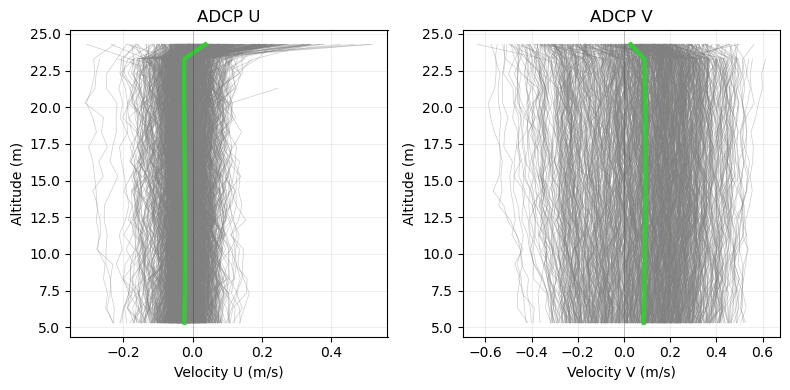

In [ ]:
# average to hourly velocities
vel_h = ds['vel'].resample(time='1h').mean()

# plot each profile in grey and average in green
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
custom.plot_profiles(vel_h[0], title='ADCP U', xlabel='Velocity U (m/s)', ylabel='Altitude (m)', ax=axes[0], mean_color='green')
custom.plot_profiles(vel_h[1], title='ADCP V', xlabel='Velocity V (m/s)', ylabel='Altitude (m)', ax=axes[1], mean_color='green')
plt.show()

### Export selected layers as dataframes for validation

In [ ]:
#resample and group by layers
ADCP_output = ds['vel'].resample(time='1h').mean().groupby_bins('range', bins=[2.3, 13.3, 24.3]).mean()
upper = ADCP_output.isel(range_bins=(1)) # upper layer 13.3m to 24.3m
lower = ADCP_output.isel(range_bins=(0)) # lower layer 2.3m to 13.3m

# convert to dataframe
ADCP_upper = pd.DataFrame({
    'date': upper.time.values,
    'velocity_U': upper[0].values,
    'velocity_V' : upper[1].values,
    'velocity_modulus' : custom.speed(upper),  # calculate speed
    'velocity_direction' : custom.direction(upper)   # calculate direction

})
ADCP_upper = ADCP_upper.set_index('date')

ADCP_lower = pd.DataFrame({
    'date': lower.time.values,
    'velocity_U': lower[0].values,
    'velocity_V' : lower[1].values,
    'velocity_modulus' : custom.speed(lower),       # calculate speed
    'velocity_direction' : custom.direction(lower)     # calculate direction

})
ADCP_lower = ADCP_lower.set_index('date')

ADCP_upper.to_csv('../../../data/ADCP/ADCP_upper_08.csv', index=True)
ADCP_lower.to_csv('../../../data/ADCP/ADCP_lower_08.csv', index=True)